In [ ]:
import tensorflow as tf
import numpy as np
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GRU, Flatten, Dense, Dropout, Reshape
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GRU
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

In [ ]:
IMAGE_SIZE = [224, 224]

In [ ]:
file_path ="/content/drive/MyDrive/Facial Emotion/ck+"

In [ ]:
datagen = ImageDataGenerator(rescale = 1./255,
                             shear_range = 0.2,
                             zoom_range = 0.2,
                             horizontal_flip = True,
                             vertical_flip=True,
                             rotation_range=30)

train_it = datagen.flow_from_directory('/content/drive/MyDrive/Facial Emotion/ck+/train',
                                       class_mode='categorical',
                                       target_size=(224,224),
                                       batch_size=32,
                                       seed=7)

test_it = datagen.flow_from_directory('/content/drive/MyDrive/Facial Emotion/ck+/test',
                                       class_mode='categorical',
                                       target_size=(224, 224),
                                       batch_size=32,
                                       seed=7)
print(train_it.class_indices)

Found 873 images belonging to 7 classes.
Found 203 images belonging to 7 classes.
{'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'sadness': 5, 'surprise': 6}


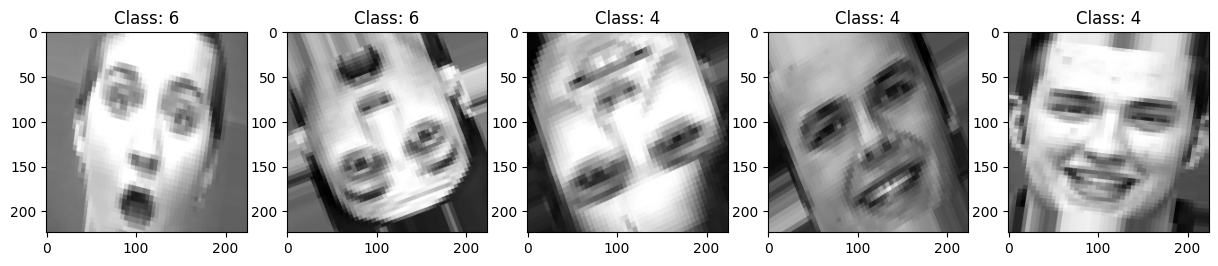

In [ ]:
import matplotlib.pyplot as plt
def plot_images(generator, num_images=5):
    images, labels = generator.next()
    plt.figure(figsize=(15,10))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        plt.title(f'Class: {labels[i].argmax()}')
plt.show()
plot_images(train_it)

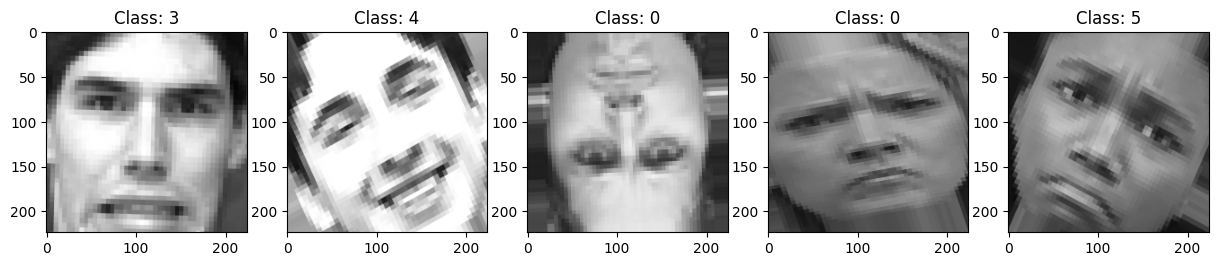

In [ ]:
import matplotlib.pyplot as plt
def plot_images(generator, num_images=5):
    images, labels = generator.next()
    plt.figure(figsize=(15, 10))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i])
        plt.title(f'Class: {labels[i].argmax()}')
plt.show()
plot_images(test_it)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, Activation, MaxPooling2D, GlobalAveragePooling2D, Dense, GRU, Reshape, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
def build_resnet(input_shape, num_classes):
    base_model = ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(256, activation='relu')(x)
    return Model(inputs=base_model.input, outputs=x)
def build_gru(input_shape, gru_units, num_classes):
    model = Sequential()
    model.add(GRU(gru_units, input_shape=input_shape))
    model.add(Dense(256, activation='relu'))
    return model
def build_resnet_gru_hybrid(input_shape, gru_units, num_classes):
    input_tensor = Input(shape=input_shape)
    resnet_model = build_resnet(input_shape, num_classes)
    resnet_output = resnet_model(input_tensor)
    gru_model = build_gru((1, 256), gru_units, num_classes)
    gru_output = gru_model(Reshape((1, 256))(resnet_output))
    combined_output = Concatenate()([resnet_output, gru_output])
    output = Dense(num_classes, activation='softmax')(combined_output)
    return Model(inputs=input_tensor, outputs=output)
input_shape = (224, 224, 3)
gru_units = 128
num_classes = 7
model = build_resnet_gru_hybrid(input_shape, gru_units, num_classes)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

94765736/94765736 [==============================] - 0s 0us/step
Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 model (Functional)          (None, 256)                  2411225   ['input_1[0][0]']             
                                                          6                                       
                                                                                                  
 reshape (Reshape)           (None, 1, 256)               0         ['model[0][0]']               
                                                                                                  
 sequential (Sequential)   

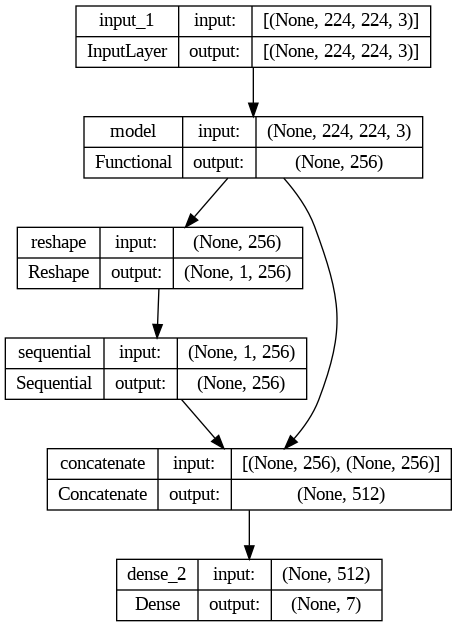

In [ ]:
tf.keras.utils.plot_model(model, to_file='model.png', show_shapes=True)

In [ ]:
history= model.fit(train_it,steps_per_epoch=len(train_it),epochs=50)

Epoch 1/50
28/28 [==============================] - 16s 548ms/step - loss: 0.0329 - accuracy: 0.9874
Epoch 2/50
28/28 [==============================] - 15s 511ms/step - loss: 0.0178 - accuracy: 0.9920
Epoch 3/50
28/28 [==============================] - 15s 537ms/step - loss: 0.0142 - accuracy: 0.9943
Epoch 4/50
28/28 [==============================] - 16s 570ms/step - loss: 0.0234 - accuracy: 0.9943
Epoch 5/50
28/28 [==============================] - 17s 591ms/step - loss: 0.0337 - accuracy: 0.9931
Epoch 6/50
28/28 [==============================] - 16s 565ms/step - loss: 0.0225 - accuracy: 0.9931
Epoch 7/50
28/28 [==============================] - 16s 570ms/step - loss: 0.0080 - accuracy: 0.9966
Epoch 8/50
28/28 [==============================] - 16s 560ms/step - loss: 0.0028 - accuracy: 1.0000
Epoch 9/50
28/28 [==============================] - 15s 521ms/step - loss: 0.0063 - accuracy: 0.9989
Epoch 10/50
28/28 [==============================] - 15s 528ms/step - loss: 0.0036 - accura

In [ ]:
print("Loss of the model is - " , model.evaluate(test_it)[0])
print("Accuracy of the model is - " ,model.evaluate(test_it)[1]*100 , "%")

7/7 [==============================] - 3s 441ms/step - loss: 0.2074 - accuracy: 0.9507
Loss of the model is -  0.20738615095615387
7/7 [==============================] - 3s 391ms/step - loss: 0.2611 - accuracy: 0.9557
Accuracy of the model is -  95.56650519371033 %


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
print("Precision of the model is - " , model.evaluate(test_it)[1]*100 , "%")
print("Recall of the model is - " , model.evaluate(test_it)[1]*100 , "%")

7/7 [==============================] - 4s 591ms/step - loss: 0.2334 - accuracy: 0.9458
Precision of the model is -  94.58128213882446 %
7/7 [==============================] - 3s 367ms/step - loss: 0.2866 - accuracy: 0.9606
Recall of the model is -  96.05911374092102 %


In [ ]:
from sklearn.metrics import f1_score
print("f1-score of the model is - " , model.evaluate(test_it)[1]*100 , "%")

7/7 [==============================] - 4s 591ms/step - loss: 0.1359 - accuracy: 0.9507
f1-score of the model is -  95.07389068603516 %


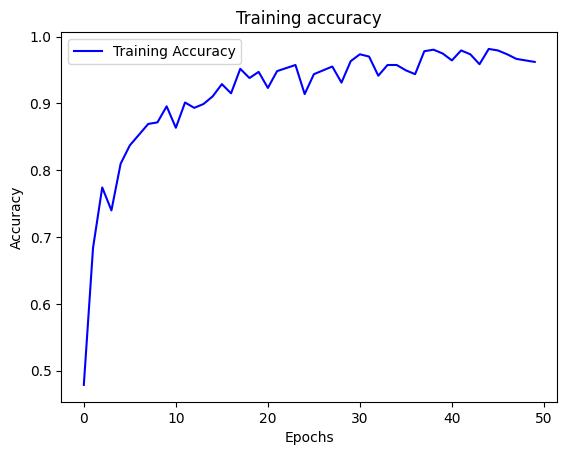

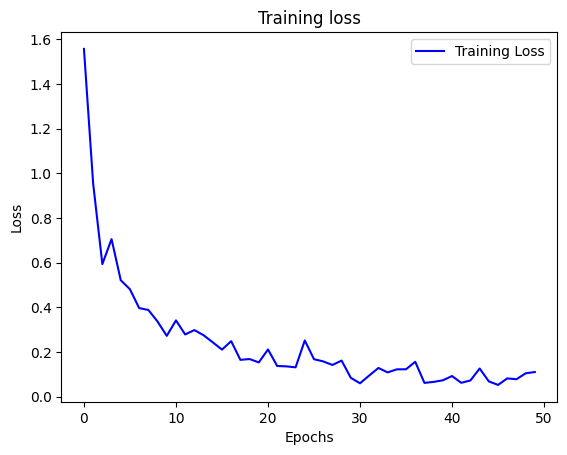

In [ ]:
accuracy = history.history['accuracy']
loss = history.history['loss']
epochs = range(len(accuracy))
plt.plot(epochs, accuracy, 'b', label='Training Accuracy')
plt.title('Training accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'b', label='Training Loss')
plt.title('Training loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<ipython-input-34-615a873cae5d>:5: UserWarning: `Model.predict_generator` is deprecated and will be removed in a future version. Please use `Model.predict`, which supports generators.
  Y_pred = model.predict_generator(test_it)


Confusion Matrix:
[[ 3  3  3  4  3  4  3]
 [ 3  4  5  1  6  2  3]
 [ 4  3  6  8  7  4  5]
 [ 3  4  6  1  5  3  3]
 [ 3  6  5  5  6  4  4]
 [ 3  2  6  1  3  3  6]
 [ 4  2  6  4  6  2 13]]


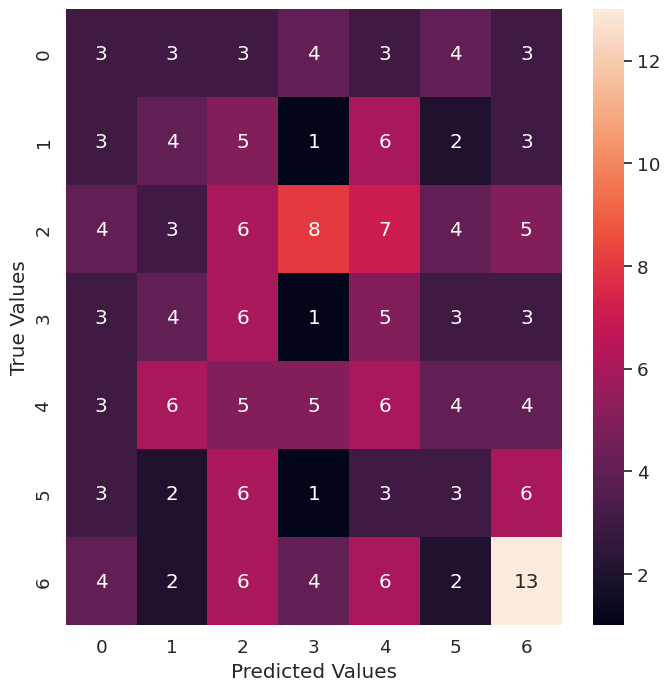

In [ ]:
import numpy as np
from keras.models import load_model
from sklearn.metrics import confusion_matrix
import seaborn as sns
Y_pred = model.predict_generator(test_it)
y_pred = np.argmax(Y_pred, axis=1)
cm = confusion_matrix(test_it.classes, y_pred)
print("Confusion Matrix:")
print(cm)
fig, ax = plt.subplots(figsize=(8, 8))
sns.set(font_scale=1.2)
cm_str = np.array([[str(int(val)) for val in row] for row in cm])
sns.heatmap(cm, annot=cm_str, fmt='', ax=ax)
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
def predict(img_name):
    img=image.load_img(img_name,target_size=(224,224))
    img=image.img_to_array(img)
    plt.imshow(img.astype('int32'))
    plt.show()
    prediction=model.predict(img.reshape(1,224,224,3))
    output=np.argmax(prediction)
    print(class_names[output])

In [ ]:
import os
class_names=os.listdir('/content/drive/MyDrive/Facial Emotion/ck+/test')
print(class_names)

['sadness', 'happy', 'surprise', 'anger', 'fear', 'contempt', 'disgust']


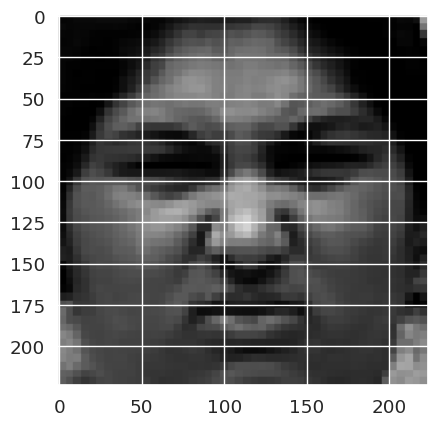

1/1 [==============================] - 0s 27ms/step
disgust


In [ ]:
predict('/content/drive/MyDrive/Facial Emotion/ck+/test/disgust/S005_001_00000011.png')

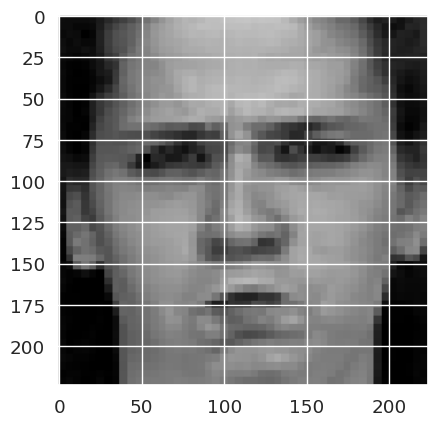

1/1 [==============================] - 0s 25ms/step
anger


In [ ]:
predict('/content/drive/MyDrive/Facial Emotion/ck+/test/anger/S127_010_00000018.png')